/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


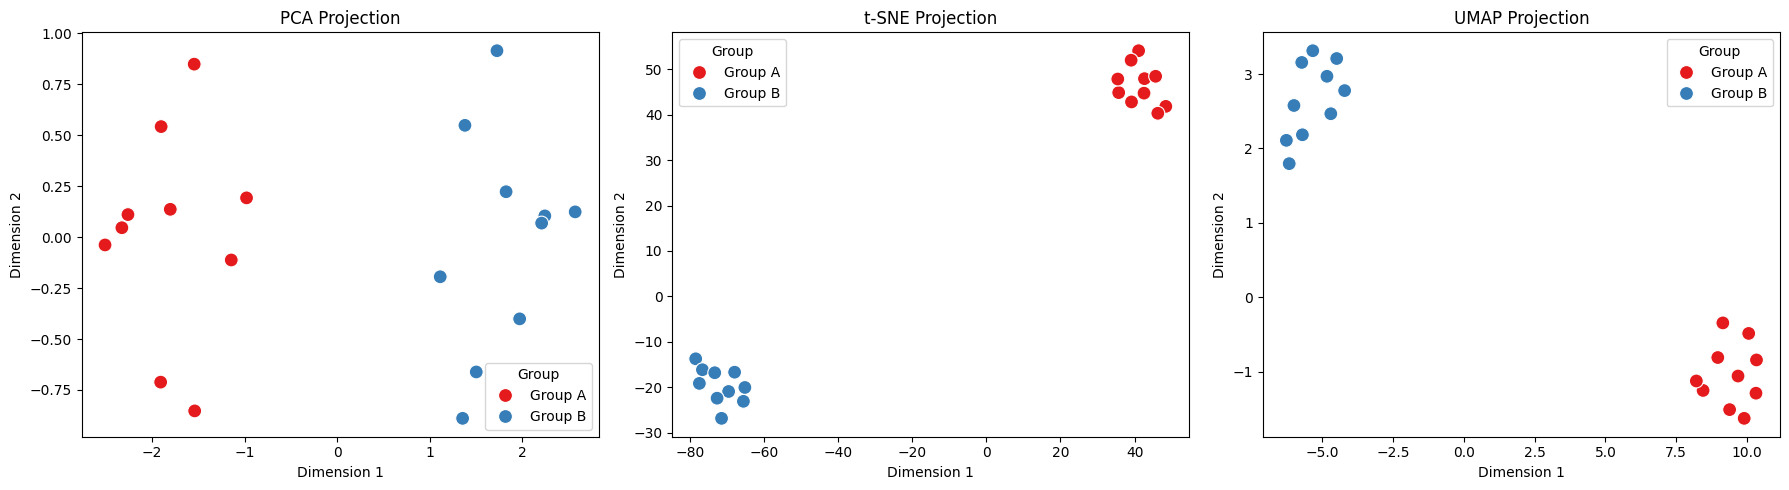

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(42)

data = np.random.randn(20, 4)
data[10:, :] += 3.5  # Create 2 groups

labels = ['Group A'] * 10 + ['Group B'] * 10

df = pd.DataFrame(
    data,
    columns=['F1', 'F2', 'F3', 'F4']
)

df['Group'] = labels

X = df[['F1', 'F2', 'F3', 'F4']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42
)

tsne_res = tsne.fit_transform(X_scaled)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    random_state=42
)

umap_res = umap_model.fit_transform(X_scaled)


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

results = [
    ('PCA', pca_res),
    ('t-SNE', tsne_res),
    ('UMAP', umap_res)
]

for ax, (title, res_data) in zip(axes, results):

    plot_df = pd.DataFrame(
        res_data,
        columns=['Dim 1', 'Dim 2']
    )

    plot_df['Group'] = labels

    sns.scatterplot(
        data=plot_df,
        x='Dim 1',
        y='Dim 2',
        hue='Group',
        palette='Set1',
        s=100,
        ax=ax
    )

    ax.set_title(f'{title} Projection')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend(title='Group')

plt.tight_layout()
plt.show()